Done!


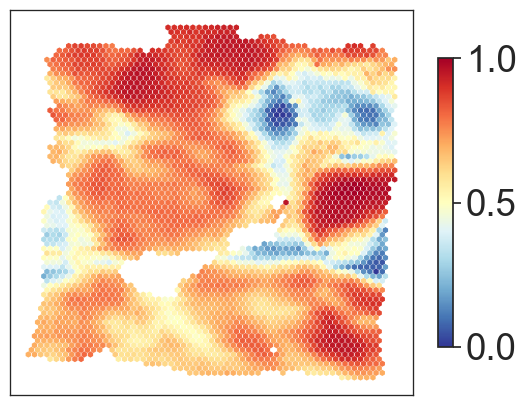

In [11]:
import numpy as np
import pandas as pd
from numpy import dot
import seaborn as sns
from scipy import stats
import matplotlib as mpl
import scipy.linalg as la
import matplotlib.cm as cm
from numpy.linalg import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LinearRegression
def normalize_array(x):
  min_val = np.min(x)
  max_val = np.max(x)
  if max_val - min_val == 0:
    return np.zeros_like(x, dtype=float)
  normalized_x = (x - min_val) / (max_val - min_val)
  return normalized_x

def rot2d(x,y, theta, unit='degree'):
    a =np.vstack([x,y]).T
    if unit == 'degree':
        theta = theta*np.pi/180 # convert to radian
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    ar=a.dot(R.T)
    return ar[:,0], ar[:,1]

def ComputePCs(X):
    cov = X.dot(X.T)
    w, v = la.eig(cov)
    idx = np.argsort(w)[::-1][:len(w)]
    w = w[idx]
    v = v[:,idx]
    for i in range(len(w)):
        if 100*sum(w[0:i+1].real)/sum(w.real)>95:
            n = i+1
            break
    pc_name = []
    for i in range(1,n+1):
        pc_name.append('PC'+str(i))
    return pd.DataFrame(v[:,0:n].real, columns = pc_name, index = X.index)
    
def ComputeEigenGene(PCs, y):
    reg = LinearRegression().fit(PCs, y)
    reg.score(PCs, y)
    alp = pd.DataFrame(reg.coef_.T, columns = ['Eigen-Gene'], index=PCs.columns)
    EigenG = PCs.dot(alp)
    return EigenG
    
def ComputeEigenPatient(X, EigenG): 
    EigenP = pd.DataFrame((X.T).dot(EigenG)).rename(columns={'Eigen-Gene':'Eigen-Patient'})
    return EigenP
    
def PlotPrediction(xloc,yloc, Cosine, Method):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    vmin, vmax = Cosine.min(), Cosine.max()
    normalize = mcolors.TwoSlopeNorm(vcenter=vmin+(vmax-vmin)*2/4, vmin=vmin, vmax=vmax) 
    DotSize=20           # Change the size of dots depending on resolution of SRT data and figure size
    
    orig_map = cm.RdYlBu
    reversed_map = orig_map.reversed() 
    s = sns.scatterplot(y = yloc, x =xloc, c = Cosine, norm = normalize, cmap = reversed_map, ax = ax,
                      marker = 'h', s = DotSize, edgecolor = 'none')
    fig.colorbar(mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(vmin, vmax), cmap=reversed_map),
             ax = ax, orientation = 'vertical', ticks=[0, 0.5, 1], shrink=0.75)

    s.set(xticklabels = []); s.set(yticklabels = [])
    s.set(xlabel = None); s.set(ylabel = None)
    ax.spines['top'].set_linewidth(0.95)
    ax.spines['bottom'].set_linewidth(0.95)
    ax.spines['left'].set_linewidth(0.95)
    ax.spines['right'].set_linewidth(0.95)

    sns.set(font_scale =2.4, style='white', font='Arial') # Change the font size depending on figure size
    plt.savefig(Method+'-Prediction-Plot.png', dpi = 300, bbox_inches = 'tight')

def ComputeROC(df, Spots, NonSpots):
    N=len(df.index)
    Core=[]
    for i in range(0, N+1, 5):
        TP = len(Spots.intersection(df.index[:i]))
        FP = i-TP
        TN = len(NonSpots.intersection(df.index[i:]))
        FN = len(df.index[i:])-TN
        Core.append([TP, FP, FN, TN, TP/(TP+FN), FP/(TN+FP)])
    return pd.DataFrame(Core, columns=['TP','FP','FN','TN','TPR','FPR']) 
# Estimation of Eigen-Patient from bulk data of cancer patients

BulkExpression = pd.read_csv('Bulk-Expr-BRCA-TCGA.csv', index_col=0)    # Load the vector of phenotype quantity]    # Load the bulk gene expression data 
PhenotypeVector = pd.read_csv('PhenotypeVector-TP-BRCA-TCGA.csv', index_col=0) 
ind = (PhenotypeVector.index).intersection(BulkExpression.index)
BulkExpression = BulkExpression.loc[ind]
PhenotypeVector = PhenotypeVector.loc[ind]

PCdata = ComputePCs(BulkExpression)                   # Compute the principal components
EigenGene = ComputeEigenGene(PCdata, PhenotypeVector) # Compute the Eigen-Gene vector
EigenGene.to_csv('Eigen-Gene.csv')                    # Save Eigen-Gene vector as a cvs file
EigenPatient = ComputeEigenPatient(BulkExpression, EigenGene) # Compute the Eigen-Patient vector
EigenPatient.to_csv('Eigen-Patient.csv')            # Save Eigen-Gene vector as a cvs file

# Prediction of phenotype on spatial locations
DataSRT = pd.read_csv('SRT-Expr-Breast-1.1.0-Smoothed.csv', index_col=0).T # SRT gene expression matrix (rows are genes, and columns are spots)
ind = (DataSRT.columns).intersection(EigenPatient.index)
DataSRT=DataSRT[ind].T
EigenPatient=EigenPatient.loc[ind]
n = len(DataSRT.columns)
# Compute cosine similartiy between Eigen-Patient and gene expression in each spot
Cosine = pd.DataFrame(np.zeros((n,1)), columns=['SpacePhenotyper'], index=DataSRT.columns)
for i in Cosine.index:
    Cosine.loc[i] = dot(EigenPatient['Eigen-Patient'], DataSRT[i])/(norm(EigenPatient['Eigen-Patient'])*norm(DataSRT[i]))  
MetaData = pd.read_csv('SRT-tissue-positions-Breast-1.1.0.csv', index_col=0) # Load spot locations in SRT data
index = (Cosine.index).intersection(MetaData.index)

MetaData = MetaData.loc[index]
Cosine = Cosine.loc[index]

Result = pd.concat([MetaData[['array_row', 'array_col']], Cosine], axis=1)
x = Result['array_row']
y = Result['array_col']

theta=-90
x, y = rot2d(x,y, theta)
Result['SpacePhenotyper'].to_csv('SpacePhenotyper-On-Spots.csv') 
PlotPrediction(x,y, normalize_array(Result['SpacePhenotyper']), 'SpacePhenotyper') # Plot the prediction of phenotype quantity
print('Done!')